# PyTorch practice, hints, Dataloaders, Conv

Credits:
* First part is based on YSDA [Practical RL course week04 materials](https://github.com/yandexdataschool/Practical_RL/tree/master/week04_%5Brecap%5D_deep_learning).
* Second part is based on PyTorch official tutorials and [this kaggle kernel](https://www.kaggle.com/pinocookie/pytorch-dataset-and-dataloader)
* Third part is based on PyTorch tutorial by [Stanford CS 231n course](http://cs231n.stanford.edu)

![img](https://pytorch.org/tutorials/_static/pytorch-logo-dark.svg)

__This notebook__ will teach you to use pytorch low-level core. You can install it [here](http://pytorch.org/).

__Pytorch feels__ differently than other frameworks (like tensorflow/theano) on almost every level. TensorFlow makes your code live in two "worlds" simultaneously:  symbolic graphs and actual tensors. First you declare a symbolic "recipe" of how to get from inputs to outputs, then feed it with actual minibatches of data.  In pytorch, __there's only one world__: all tensors have a numeric value.

You compute outputs on the fly without pre-declaring anything. The code looks exactly as in pure numpy with one exception: pytorch computes gradients for you. And can run stuff on GPU. And has a number of pre-implemented building blocks for your neural nets. [And a few more things.](https://medium.com/towards-data-science/pytorch-vs-tensorflow-spotting-the-difference-25c75777377b)

Let's dive into it!

In [1]:
! pip install pandas

In [2]:
import matplotlib.pyplot as plt
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

### Task 1: Tensormancy

__1.1 The [_disclaimer_](https://gist.githubusercontent.com/justheuristic/e2c1fa28ca02670cabc42cacf3902796/raw/fd3d935cef63a01b85ed2790b5c11c370245cbd7/stddisclaimer.h)__

Let's write another function, this time in polar coordinates:
$$\rho(\theta) = (1 + 0.9 \cdot cos (6 \cdot \theta) ) \cdot (1 + 0.01 \cdot cos(24 \cdot \theta)) \cdot (0.5 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (10 + sin(10 \cdot \theta))$$


Then convert it into cartesian coordinates ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html)) and plot the results.

Use torch tensors only: no lists, loops, numpy arrays, etc.

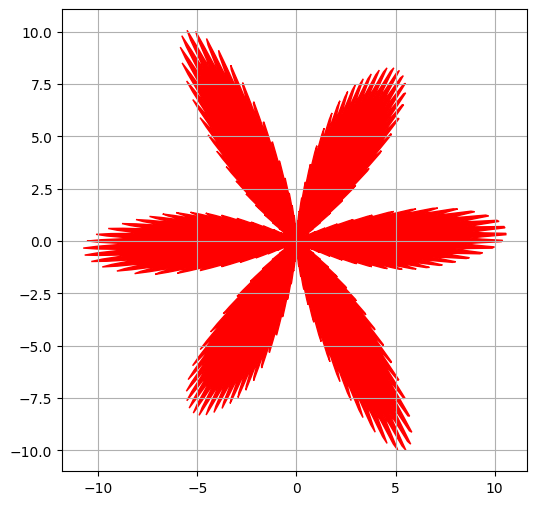

In [3]:
# creates a one-dimensional tensor
theta = torch.linspace(-np.pi, np.pi, steps=1000)

# compute rho(theta) as per formula above
# ρ(θ)=(1+0.9·cos(6·θ))·(1+0.01·cos(24·θ))·(0.5+0.05·cos(200·θ))·(10+sin(10·θ))
rho = (
    (1 + 0.9 * torch.cos(6 * theta))
    * (1 + 0.01 * torch.cos(24 * theta))
    * (0.5 + 0.05 * torch.cos(200 * theta))
    * (10 + torch.sin(10 * theta))
)

# Now convert polar (rho, theta) pairs into cartesian (x,y) to plot them
x = rho * torch.cos(theta)
y = rho * torch.sin(theta)

plt.figure(figsize=(6, 6))
plt.fill(x.numpy(), y.numpy(), color="red")
plt.grid()

### Task 2: Using the Dataloader

In [4]:
from torch import nn
from torch.nn import functional as F

In [5]:
!wget https://raw.githubusercontent.com/neychev/harbour_ml2020/master/day10_Optimization_and_regularization_in_DL/notmnist.py

--2025-04-24 14:13:59--  https://raw.githubusercontent.com/neychev/harbour_ml2020/master/day10_Optimization_and_regularization_in_DL/notmnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1799 (1.8K) [text/plain]
Saving to: ‘notmnist.py’

notmnist.py         100%[===================>]   1.76K  --.-KB/s    in 0s      

2025-04-24 14:14:00 (31.5 MB/s) - ‘notmnist.py’ saved [1799/1799]



In [6]:
!pip install scikit-learn

In [7]:
from notmnist import load_notmnist

X_train, y_train, X_test, y_test = load_notmnist()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 8259k  100 8259k    0     0  4957k      0  0:00:01  0:00:01 --:--:-- 4954k


Extracting ...
Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset` that allow you to use pre-loaded datasets as well as your own data. `Dataset` stores the samples and their corresponding labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access to the samples.

In [8]:
print(Dataset.__doc__)

An abstract class representing a :class:`Dataset`.

    All datasets that represent a map from keys to data samples should subclass
    it. All subclasses should overwrite :meth:`__getitem__`, supporting fetching a
    data sample for a given key. Subclasses could also optionally overwrite
    :meth:`__len__`, which is expected to return the size of the dataset by many
    :class:`~torch.utils.data.Sampler` implementations and the default options
    of :class:`~torch.utils.data.DataLoader`. Subclasses could also
    optionally implement :meth:`__getitems__`, for speedup batched samples
    loading. This method accepts list of indices of samples of batch and returns
    list of samples.

    .. note::
      :class:`~torch.utils.data.DataLoader` by default constructs an index
      sampler that yields integral indices.  To make it work with a map-style
      dataset with non-integral indices/keys, a custom sampler must be provided.
    


In [9]:
import cv2

In [10]:
class DatasetMNIST(Dataset):
    def __init__(self, path="./notMNIST_small", letters="ABCDEFGHIJ", transform=None):
        self.data, self.labels, _, _ = load_notmnist(
            path=path, letters=letters, test_size=0
        )
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        # load image as ndarray type (Height * Width * Channels)
        # be carefull for converting dtype to np.uint8 [Unsigned integer (0 to 255)]
        # in this example, i don't use ToTensor() method of torchvision.transforms        
        image = self.data[index].transpose(1, 2, 0)
        label = self.labels[index]
        # so you can convert numpy ndarray shape to tensor in PyTorch (C, H, W) --> (H, W, C)
        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [11]:
full_dataset = DatasetMNIST("./notMNIST_small", "AB", transform=None)

Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


In [12]:
# we can access and get data with index by __getitem__(index)
img, lab = full_dataset.__getitem__(0)

print(img.shape)
print(type(img))

(28, 28, 1)
<class 'numpy.ndarray'>


In [13]:
full_dataset.__len__()

3745

In [14]:
a = torchvision.transforms.ToTensor()

print(img.shape)

new_img = a(img)

print(new_img.shape)

(28, 28, 1)
torch.Size([1, 28, 28])


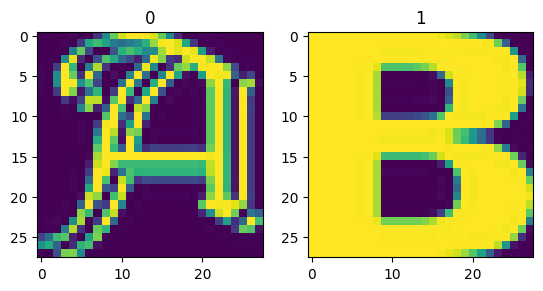

In [15]:
inds = np.random.randint(len(full_dataset), size=2)

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(full_dataset[inds[i]][0].reshape([28, 28]))
    plt.title(str(full_dataset[inds[i]][1]))

#### To the DataLoader

The `Dataset` retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

`DataLoader` is an iterable that abstracts this complexity for us in an easy API.

We have loaded that dataset into the `DataLoader` and can iterate through the dataset as needed. Each iteration below returns a batch of train_features and train_labels (containing `batch_size=8` features and labels respectively). Because we specified `shuffle=True`, after we iterate over all batches the data is shuffled

In [16]:
train_loader = DataLoader(full_dataset, batch_size=8, shuffle=True, num_workers=1)

We can use dataloader as iterator by using iter() function.

In [17]:
train_iter = iter(train_loader)
print(type(train_iter))

<class 'torch.utils.data.dataloader._MultiProcessingDataLoaderIter'>


We can look at images and labels of batch size by extracting data `.next()` method.

In [18]:
images, labels = next(train_iter)
# images, labels = train_iter.__next__()

print("images shape on batch size = {}".format(images.size()))
print("labels shape on batch size = {}".format(labels.size()))

labels.numpy()

images shape on batch size = torch.Size([8, 28, 28, 1])
labels shape on batch size = torch.Size([8])


array([1, 0, 0, 0, 1, 1, 0, 1])

Initital images:  torch.Size([8, 28, 28, 1])
Permute images:  torch.Size([8, 1, 28, 28])
Rescale images:  torch.Size([8, 1, 28, 28])
Grid shape torch.Size([3, 32, 242])
Np Grid shape (32, 242, 3)


Text(0.5, 1.0, '[1 0 0 0 1 1 0 1]')

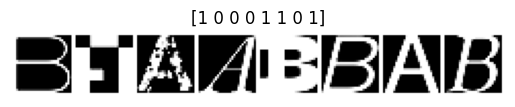

In [19]:
# tensor : (batchsize, channels, height, width)
# Assuming images are in (B, H, W, C) format (e.g., from PIL/numpy loading)
print('Initital images: ', images.shape)

if images.dim() == 4 and images.size(1) != 3:  # If channels aren't in position 1
    images = images.permute(0, 3, 1, 2)  # (B, H, W, C) -> (B, C, H, W)

print('Permute images: ', images.shape)

# Normalize images to [0,1] range if they aren't already
# https://en.wikipedia.org/wiki/Feature_scaling
# if images.min() < 0 or images.max() > 1:
#     images = (images - images.min()) / (images.max() - images.min())

print('Rescale images: ', images.shape)

# Create grid (now expects (B, C, H, W))
grid = torchvision.utils.make_grid(images, scale_each=True, value_range = (0, 1), pad_value=5)
print("Grid shape", grid.shape)
# images.shape

# Convert to numpy and change to (H, W, C) for matplotlib
grid_np = grid.numpy().transpose(1, 2, 0)
print("Np Grid shape", grid_np.shape)

plt.imshow(grid_np)
plt.axis("off")
plt.title(str(labels.numpy()))

And now with transformations:

In [20]:
train_dataset_with_transform = DatasetMNIST(transform=torchvision.transforms.ToTensor())

Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


In [21]:
img, lab = train_dataset_with_transform.__getitem__(0)

print("image shape at the first row : {}".format(img.size()))

image shape at the first row : torch.Size([1, 28, 28])


In [22]:
train_loader_tr = DataLoader(train_dataset_with_transform, batch_size=8, shuffle=True)

train_iter_tr = iter(train_loader_tr)
print(type(train_iter_tr))

images, labels = next(train_iter_tr)

print("images shape on batch size = {}".format(images.size()))
print("labels shape on batch size = {}".format(labels.size()))

<class 'torch.utils.data.dataloader._SingleProcessDataLoaderIter'>
images shape on batch size = torch.Size([8, 1, 28, 28])
labels shape on batch size = torch.Size([8])


Text(0.5, 1.0, '[1 8 3 7 1 4 6 2]')

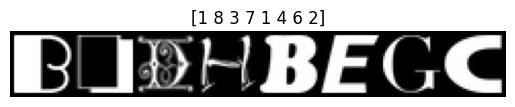

In [23]:
if images.min() < 0 or images.max() > 1:
    images = (images - images.min()) / (images.max() - images.min())

grid = torchvision.utils.make_grid(images)

plt.imshow(grid.numpy().transpose((1, 2, 0)))
plt.axis("off")
plt.title(str(labels.numpy()))

### Composing several transformations

If you want to take data augmentation, you have to make List using `torchvision.transforms.Compose`

```
class Compose(object):
    """Composes several transforms together.
    Args:
        transforms (list of ``Transform`` objects): list of transforms to compose.
    Example:
        >>> transforms.Compose([
        >>>     transforms.CenterCrop(10),
        >>>     transforms.ToTensor(),
        >>> ])
    """

    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img):
        for t in self.transforms:
            img = t(img)
        return img

    def __repr__(self):
        format_string = self.__class__.__name__ + '('
        for t in self.transforms:
            format_string += '\n'
            format_string += '    {0}'.format(t)
        format_string += '\n)'
        return format_string
```


this function can convert some image by order within `__call__` method.

In [24]:
class Flatten:
    def __call__(self, pic):
        return pic.flatten()

    def __repr__(self):
        return self.__class__.__name__ + "()"

In [25]:
a = Flatten()

In [26]:
print(a)

Flatten()


In [27]:
print(a(img).shape)

torch.Size([784])


In [28]:
a(img).shape.__repr__()

'torch.Size([784])'

In [29]:
flatten_transform = Flatten()

# Применяем к изображению
flattened_img = flatten_transform(img)

print(flattened_img.shape)  # Вывод: torch.Size([3072])  (3 * 32 * 32 = 3072)

torch.Size([784])


In [30]:
new_transform = torchvision.transforms.Compose(
    [

        #     torchvision.transforms.CenterCrop(),

        #     torchvision.transforms.Resize((640, 460)),

        torchvision.transforms.ToTensor(),

        Flatten(),

    ]
)

# Putting all together

In [31]:
import time

from IPython.display import clear_output

In [32]:
# use GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [33]:
def subset_ind(dataset, ratio: float):
    #     return ### YOUR CODE HERE
    return np.random.choice(len(dataset), size=int(ratio * len(dataset)), replace=False)

In [34]:
dataset = DatasetMNIST(
    "./notMNIST_small",
    # 'AB',
    transform=new_transform,
)

shrink_inds = subset_ind(dataset, 0.2)
dataset = Subset(dataset, shrink_inds)

print(f"\n\n dataset size: {len(dataset)}, labels: {np.unique(dataset.dataset.labels)}")

Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


 dataset size: 3744, labels: [0 1 2 3 4 5 6 7 8 9]


In [35]:
val_size = 0.2
val_inds = subset_ind(dataset, val_size)

train_dataset = Subset(dataset, [i for i in range(len(dataset)) if i not in val_inds])
val_dataset = Subset(dataset, val_inds)

print(f"  training size: {len(train_dataset)}\nvalidation size: {len(val_dataset)}")

  training size: 2996
validation size: 748


In [36]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [37]:
train_iter = iter(train_loader)
print(type(train_iter))

images, labels = train_iter.__next__()

print("images shape on batch size = {}".format(images.size()))
print("labels shape on batch size = {}".format(labels.size()))

<class 'torch.utils.data.dataloader._SingleProcessDataLoaderIter'>
images shape on batch size = torch.Size([32, 784])
labels shape on batch size = torch.Size([32])


In [38]:
loss_func = nn.CrossEntropyLoss()

In [39]:
default_dtype = torch.float32

In [40]:
# create network again just in case
model = nn.Sequential(
    nn.Linear(784, 10),
    nn.Sigmoid(),
)
model.to(device, default_dtype)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [41]:
preds = torch.rand(3, 10)
preds

tensor([[0.8999, 0.9861, 0.9501, 0.4704, 0.0488, 0.6215, 0.8977, 0.0873, 0.2342,
         0.8134],
        [0.4845, 0.3784, 0.7511, 0.3234, 0.3035, 0.1237, 0.9211, 0.0374, 0.6545,
         0.9624],
        [0.6629, 0.8507, 0.9481, 0.3860, 0.0441, 0.5388, 0.7601, 0.0645, 0.0982,
         0.9766]])

In [42]:
vals, inds = preds.max(axis=-1)

In [43]:
inds

tensor([1, 9, 9])

In [44]:
vals

tensor([0.9861, 0.9624, 0.9766])

In [45]:
def train_model(
    model, train_loader, val_loader, loss_fn, opt, n_epochs: int, device=device
):
    """
    model: nn tp train
    train_loader, val_loader: data loaders
    loss_fn: loss function to minimize
    opt: optimizer to update NN weights using gradient descent
    n_epochs: number of epochs = number of full data iterations
    """
    train_loss = []
    val_loss = []
    val_accuracy = []
    for epoch in range(n_epochs):
        ep_train_loss = []
        ep_val_loss = []
        ep_val_accuracy = []
        start_time = time.time()
        model.train(True)  # enable dropout / batch_norm training behavior
        for X_batch, y_batch in train_loader:
            # move data to target device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # train on batch: compute loss, calc grads, perform optimizer step and zero the grads
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_train_loss.append(loss.item())
        model.train(False)  # disable dropout / use averages for batch_norm

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                # move data to target device
                # YOUR CODE HERE
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = loss_fn(preds, y_batch)
                # compute predictions
                # YOUR CODE HERE
                ep_val_loss.append(loss.item())  # YOUR CODE HERE
                y_pred = preds.max(-1)[1]  # YOUR CODE HERE
                ep_val_accuracy.append(
                    (y_pred == y_batch).to(default_dtype).mean().item()
                )  # YOUR CODE HERE

        # print the results for this epoch:

        print(f"Epoch {epoch + 1} of {n_epochs} took {time.time() - start_time:.3f}s")

        train_loss.append(np.mean(ep_train_loss))
        val_loss.append(np.mean(ep_val_loss))
        val_accuracy.append(np.mean(ep_val_accuracy))

        print(f"\t  training loss: {train_loss[-1]:.6f}")
        print(f"\tvalidation loss: {val_loss[-1]:.6f}")
        print(f"\tvalidation accuracy: {val_accuracy[-1]:.3f}")

    return train_loss, val_loss, val_accuracy

In [46]:
n_epochs = 30

train_loss, val_loss, val_accuracy = train_model(
    model, train_loader, val_loader, loss_func, opt, n_epochs
)

Epoch 1 of 30 took 0.671s
	  training loss: 1.839438
	validation loss: 1.716023
	validation accuracy: 0.851
Epoch 2 of 30 took 0.166s
	  training loss: 1.692762
	validation loss: 1.671391
	validation accuracy: 0.879
Epoch 3 of 30 took 0.166s
	  training loss: 1.657912
	validation loss: 1.653751
	validation accuracy: 0.872
Epoch 4 of 30 took 0.170s
	  training loss: 1.638551
	validation loss: 1.637982
	validation accuracy: 0.885
Epoch 5 of 30 took 0.169s
	  training loss: 1.625078
	validation loss: 1.631680
	validation accuracy: 0.874
Epoch 6 of 30 took 0.164s
	  training loss: 1.615766
	validation loss: 1.630160
	validation accuracy: 0.871
Epoch 7 of 30 took 0.164s
	  training loss: 1.607935
	validation loss: 1.622446
	validation accuracy: 0.867
Epoch 8 of 30 took 0.167s
	  training loss: 1.601256
	validation loss: 1.619748
	validation accuracy: 0.878
Epoch 9 of 30 took 0.176s
	  training loss: 1.596626
	validation loss: 1.614582
	validation accuracy: 0.884
Epoch 10 of 30 took 0.170s
	

In [47]:
def plot_train_process(train_loss, val_loss, val_accuracy):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].set_title("Loss")
    axes[0].plot(train_loss, label="train")
    axes[0].plot(val_loss, label="validation")
    axes[0].legend()

    axes[1].set_title("Validation accuracy")
    axes[1].plot(val_accuracy)

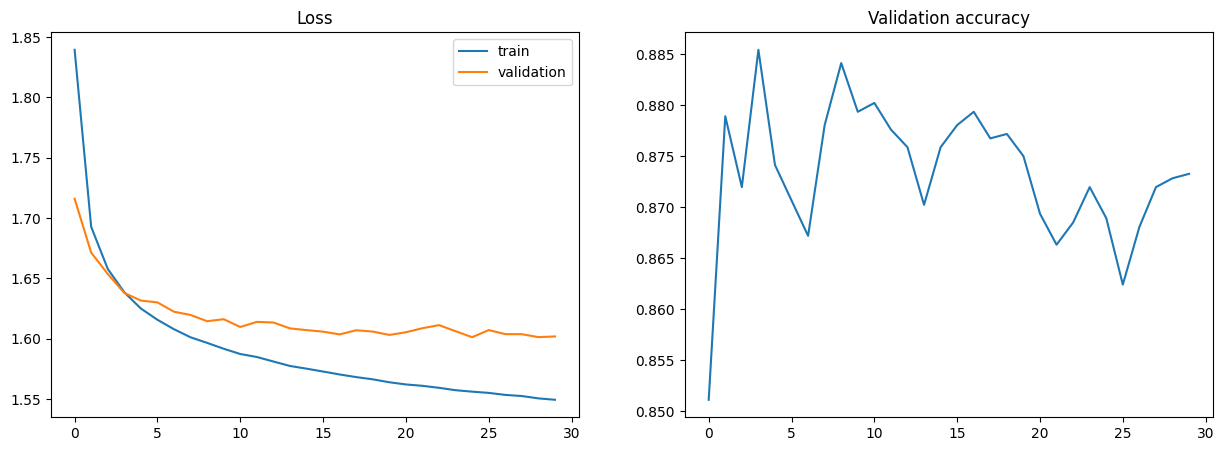

In [48]:
plot_train_process(train_loss, val_loss, val_accuracy)

## Real network

In [49]:
# create network again just in case
model = nn.Sequential(
    nn.Linear(784, 500),
    nn.ReLU(),
    nn.Linear(500, 200),
    nn.ReLU(),
    nn.Linear(200, 10),
    nn.Sigmoid(),
)
model.to(device, torch.float32)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [50]:
n_epochs = 30

train_loss, val_loss, val_accuracy = train_model(
    model, train_loader, val_loader, loss_func, opt, n_epochs
)

Epoch 1 of 30 took 0.277s
	  training loss: 1.689717
	validation loss: 1.578029
	validation accuracy: 0.878
Epoch 2 of 30 took 0.225s
	  training loss: 1.560092
	validation loss: 1.565667
	validation accuracy: 0.888
Epoch 3 of 30 took 0.225s
	  training loss: 1.534287
	validation loss: 1.559135
	validation accuracy: 0.893
Epoch 4 of 30 took 0.218s
	  training loss: 1.518784
	validation loss: 1.552853
	validation accuracy: 0.902
Epoch 5 of 30 took 0.217s
	  training loss: 1.513407
	validation loss: 1.562044
	validation accuracy: 0.890
Epoch 6 of 30 took 0.220s
	  training loss: 1.507399
	validation loss: 1.559696
	validation accuracy: 0.895
Epoch 7 of 30 took 0.214s
	  training loss: 1.513129
	validation loss: 1.555166
	validation accuracy: 0.900
Epoch 8 of 30 took 0.215s
	  training loss: 1.501589
	validation loss: 1.552770
	validation accuracy: 0.904
Epoch 9 of 30 took 0.217s
	  training loss: 1.497904
	validation loss: 1.549718
	validation accuracy: 0.901
Epoch 10 of 30 took 0.226s
	

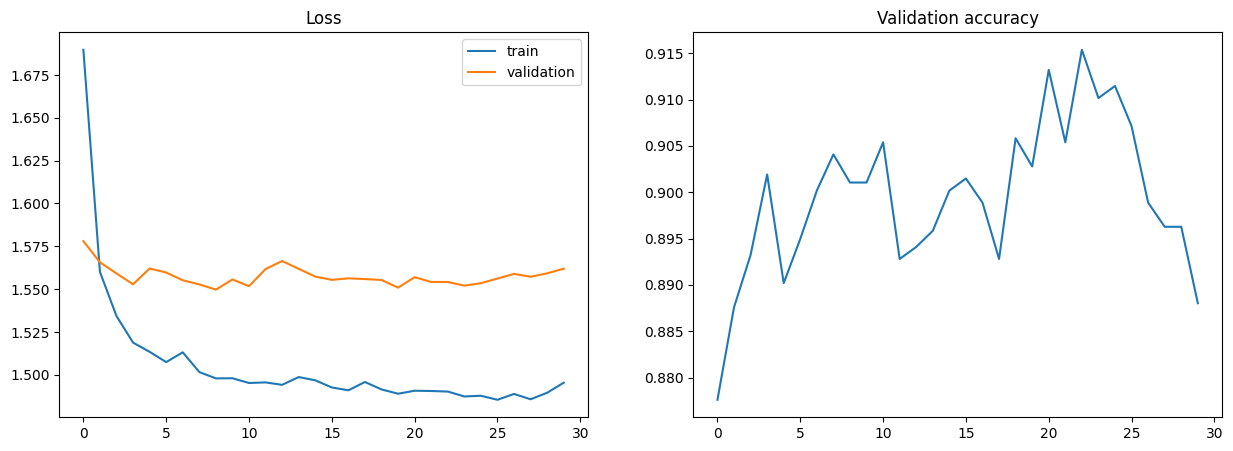

In [51]:
plot_train_process(train_loss, val_loss, val_accuracy)

In [52]:
import torchsummary

In [53]:
torchsummary.summary(model, (784,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 500]         392,500
              ReLU-2                  [-1, 500]               0
            Linear-3                  [-1, 200]         100,200
              ReLU-4                  [-1, 200]               0
            Linear-5                   [-1, 10]           2,010
           Sigmoid-6                   [-1, 10]               0
Total params: 494,710
Trainable params: 494,710
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 1.89
Estimated Total Size (MB): 1.90
----------------------------------------------------------------


## Overfit!!!

In [54]:
# create network again just in case
model = nn.Sequential(
    nn.Linear(784, 600),
    nn.ReLU(),
    nn.Linear(600, 500),
    nn.ReLU(),
    nn.Linear(500, 400),
    nn.ReLU(),
    nn.Linear(400, 200),
    nn.ReLU(),
    nn.Linear(200, 10),
    nn.Sigmoid(),
)
model.to(device, torch.float32)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [55]:
n_epochs = 30

train_loss, val_loss, val_accuracy = train_model(
    model, train_loader, val_loader, loss_func, opt, n_epochs
)

Epoch 1 of 30 took 0.273s
	  training loss: 1.754503
	validation loss: 1.679169
	validation accuracy: 0.653
Epoch 2 of 30 took 0.275s
	  training loss: 1.621541
	validation loss: 1.606049
	validation accuracy: 0.781
Epoch 3 of 30 took 0.273s
	  training loss: 1.586220
	validation loss: 1.608350
	validation accuracy: 0.771
Epoch 4 of 30 took 0.274s
	  training loss: 1.590816
	validation loss: 1.648515
	validation accuracy: 0.679
Epoch 5 of 30 took 0.285s
	  training loss: 1.601435
	validation loss: 1.614634
	validation accuracy: 0.767
Epoch 6 of 30 took 0.274s
	  training loss: 1.584452
	validation loss: 1.608302
	validation accuracy: 0.764
Epoch 7 of 30 took 0.279s
	  training loss: 1.581482
	validation loss: 1.633969
	validation accuracy: 0.747
Epoch 8 of 30 took 0.281s
	  training loss: 1.575766
	validation loss: 1.602136
	validation accuracy: 0.783
Epoch 9 of 30 took 0.276s
	  training loss: 1.598023
	validation loss: 1.624028
	validation accuracy: 0.673
Epoch 10 of 30 took 0.286s
	

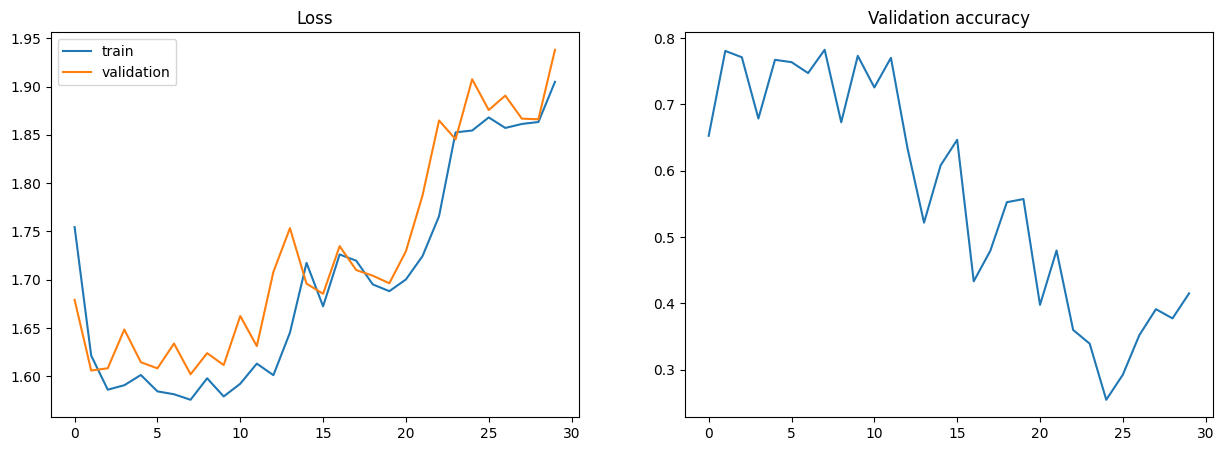

In [56]:
plot_train_process(train_loss, val_loss, val_accuracy)

## Your turn
Try to add some additional transformations (e.g. random crop, rotation etc.) and train your model!

### Dropout and Batchnorm try

In [57]:
model = nn.Sequential(
    nn.Linear(784, 600),
    nn.BatchNorm1d(600),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(600, 500),
    nn.BatchNorm1d(500),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(500, 400),
    nn.BatchNorm1d(400),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(400, 200),
    nn.BatchNorm1d(200),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(200, 10),
    nn.Sigmoid(),
)
model.to(device, torch.float32)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [58]:
n_epochs = 30

train_loss, val_loss, val_accuracy = train_model(
    model, train_loader, val_loader, loss_func, opt, n_epochs
)

Epoch 1 of 30 took 0.453s
	  training loss: 1.800616
	validation loss: 1.600620
	validation accuracy: 0.888
Epoch 2 of 30 took 0.364s
	  training loss: 1.604109
	validation loss: 1.573738
	validation accuracy: 0.894
Epoch 3 of 30 took 0.371s
	  training loss: 1.575104
	validation loss: 1.571992
	validation accuracy: 0.886
Epoch 4 of 30 took 0.364s
	  training loss: 1.554922
	validation loss: 1.563041
	validation accuracy: 0.895
Epoch 5 of 30 took 0.370s
	  training loss: 1.544179
	validation loss: 1.553892
	validation accuracy: 0.900
Epoch 6 of 30 took 0.399s
	  training loss: 1.546800
	validation loss: 1.547316
	validation accuracy: 0.906
Epoch 7 of 30 took 0.412s
	  training loss: 1.536008
	validation loss: 1.549602
	validation accuracy: 0.909
Epoch 8 of 30 took 0.376s
	  training loss: 1.529815
	validation loss: 1.551981
	validation accuracy: 0.895
Epoch 9 of 30 took 0.385s
	  training loss: 1.524621
	validation loss: 1.550854
	validation accuracy: 0.909
Epoch 10 of 30 took 0.376s
	

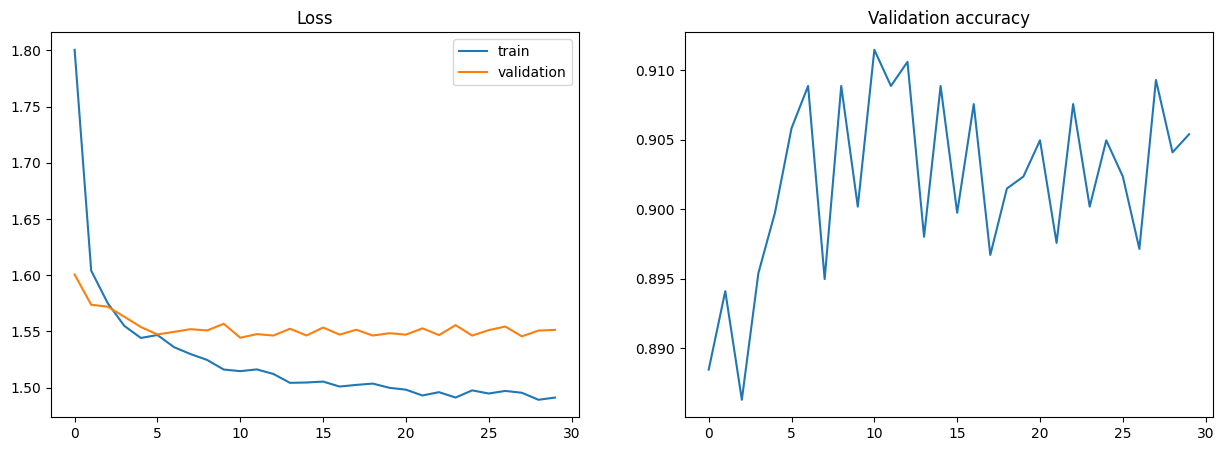

In [59]:
plot_train_process(train_loss, val_loss, val_accuracy)

### 3. Save the model (model checkpointing)

Now we have trained a model! Obviously we do not want to retrain the model everytime we want to use it. Plus if you are training a super big model, you probably want to save checkpoint periodically so that you can always fall back to the last checkpoint in case something bad happened or you simply want to test models at different training iterations.

Model checkpointing is fairly simple in PyTorch. First, we define a helper function that can save a model to the disk

In [60]:
def save_checkpoint(checkpoint_path, model, optimizer):
    # state_dict: a Python dictionary object that:
    # - for a model, maps each layer to its parameter tensor;
    # - for an optimizer, contains info about the optimizer’s states and hyperparameters used.
    state = {"state_dict": model.state_dict(), "optimizer": optimizer.state_dict()}
    torch.save(state, checkpoint_path)
    print("model saved to %s" % checkpoint_path)


def load_checkpoint(checkpoint_path, model, optimizer):
    state = torch.load(checkpoint_path)
    model.load_state_dict(state["state_dict"])
    optimizer.load_state_dict(state["optimizer"])
    print("model loaded from %s" % checkpoint_path)

In [61]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 600)
        self.bn1 = nn.BatchNorm1d(600)
        self.fc2 = nn.Linear(600, 500)
        self.bn2 = nn.BatchNorm1d(500)
        self.fc3 = nn.Linear(500, 400)
        self.bn3 = nn.BatchNorm1d(400)
        self.fc4 = nn.Linear(400, 200)
        self.bn4 = nn.BatchNorm1d(200)
        self.fc5 = nn.Linear(200, 10)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten the input
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc5(x))
        return x

In [62]:
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

#### Define a training loop with model checkpointing

In [63]:
def test(model):
    model.train(False)  # disable dropout / use averages for batch_norm
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            # move data to target device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch)
            test_loss = F.nll_loss(preds, y_batch)

            # compute predictions
            y_pred = preds.max(-1)[1]
            test_accuracy = (y_pred == y_batch).to(default_dtype).mean().item()

    print(f"\ttest loss: {test_loss:.6f}")
    print(f"\ttest accuracy: {test_accuracy:.3f}")

In [64]:
def train_save(epoch, save_interval, log_interval=100):
    model.train()  # set training mode
    iteration = 0
    for ep in range(epoch):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = F.nll_loss(output, target)
            loss.backward()
            optimizer.step()
            if iteration % log_interval == 0:
                print(
                    "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                        ep,
                        batch_idx * len(data),
                        len(train_loader.dataset),
                        100.0 * batch_idx / len(train_loader),
                        loss.item(),
                    )
                )
            # different from before: saving model checkpoints
            if iteration % save_interval == 0 and iteration > 0:
                save_checkpoint("mnist-%i.pth" % iteration, model, optimizer)
            iteration += 1

    test(model)
    # save the final model
    save_checkpoint("mnist-%i.pth" % iteration, model, optimizer)

In [65]:
train_save(5, save_interval=500, log_interval=100)

Train Epoch: 0 [0/2996 (0%)]	Loss: -0.504827
Train Epoch: 1 [192/2996 (6%)]	Loss: -0.728054
Train Epoch: 2 [384/2996 (13%)]	Loss: -0.867952
Train Epoch: 3 [576/2996 (19%)]	Loss: -0.909627
Train Epoch: 4 [768/2996 (26%)]	Loss: -0.939023
	test loss: -0.940705
	test accuracy: 0.833
model saved to mnist-470.pth


In [66]:
# create a new model
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# load from the final checkpoint
load_checkpoint("mnist-470.pth", model, optimizer)
# should give you the final model accuracy
test(model)

model loaded from mnist-470.pth
	test loss: -0.917721
	test accuracy: 0.667


/tmp/ipykernel_31/1567166835.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path)


In [67]:
train_save(5, save_interval=500, log_interval=100)

Train Epoch: 0 [0/2996 (0%)]	Loss: -0.938012
Train Epoch: 1 [192/2996 (6%)]	Loss: -0.950023
Train Epoch: 2 [384/2996 (13%)]	Loss: -0.963322
Train Epoch: 3 [576/2996 (19%)]	Loss: -0.968887
Train Epoch: 4 [768/2996 (26%)]	Loss: -0.967133
	test loss: -0.942747
	test accuracy: 0.583
model saved to mnist-470.pth


### 4. Convolutions and derivatives understanding

Animation in Figure illustrates a convolution for a 3x3 kernel applied to 3 channels of 5x5 inputs with no padding and using unit stride to get 1 output channel.

- [Back-propagation in a convolution layer with numpy implementation](https://numbersmithy.com/back-propagation-in-a-convolution-layer-with-numpy-implementation/) <-- math + practice 💪

- [Backpropagation In Convolutional Neural Networks](https://www.jefkine.com/general/2016/09/05/backpropagation-in-convolutional-neural-networks/) <-- best one 💯

- [Derivation of Backpropagation in Convolutional Neural Network (CNN)](https://www.quarkml.com/2023/07/backward-pass-in-convolutional-neural-network-explained.html) <-- with some .gif vizualization 📺

### 5. Model with Convolutions

In [68]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10),
    nn.Sigmoid(),
)
model.to(device, torch.float32)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [69]:
# Define transforms for data preprocessing
new_transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),  # output dist [-1, 1]
    ]
)

In [70]:
# Load full dataset and create subset
full_dataset = DatasetMNIST("./notMNIST_small", "AB", transform=new_transform)
shrink_inds = subset_ind(full_dataset, 0.2)
dataset = Subset(full_dataset, shrink_inds)

# Split into train/validation
val_size = 0.2
val_inds = subset_ind(dataset, val_size)
train_dataset = Subset(dataset, [i for i in range(len(dataset)) if i not in val_inds])
val_dataset = Subset(dataset, val_inds)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


In [71]:
n_epochs = 10

train_loss, val_loss, val_accuracy = train_model(
    model, train_loader, val_loader, loss_func, opt, n_epochs
)

Epoch 1 of 10 took 0.857s
	  training loss: 1.931159
	validation loss: 1.849083
	validation accuracy: 0.950
Epoch 2 of 10 took 0.224s
	  training loss: 1.684552
	validation loss: 1.641687
	validation accuracy: 0.956
Epoch 3 of 10 took 0.255s
	  training loss: 1.589038
	validation loss: 1.564393
	validation accuracy: 0.972
Epoch 4 of 10 took 0.226s
	  training loss: 1.542316
	validation loss: 1.533131
	validation accuracy: 0.978
Epoch 5 of 10 took 0.219s
	  training loss: 1.518992
	validation loss: 1.513649
	validation accuracy: 0.981
Epoch 6 of 10 took 0.225s
	  training loss: 1.505647
	validation loss: 1.505473
	validation accuracy: 0.981
Epoch 7 of 10 took 0.223s
	  training loss: 1.496352
	validation loss: 1.501671
	validation accuracy: 0.978
Epoch 8 of 10 took 0.226s
	  training loss: 1.488899
	validation loss: 1.496315
	validation accuracy: 0.972
Epoch 9 of 10 took 0.219s
	  training loss: 1.488983
	validation loss: 1.488880
	validation accuracy: 0.984
Epoch 10 of 10 took 0.225s
	

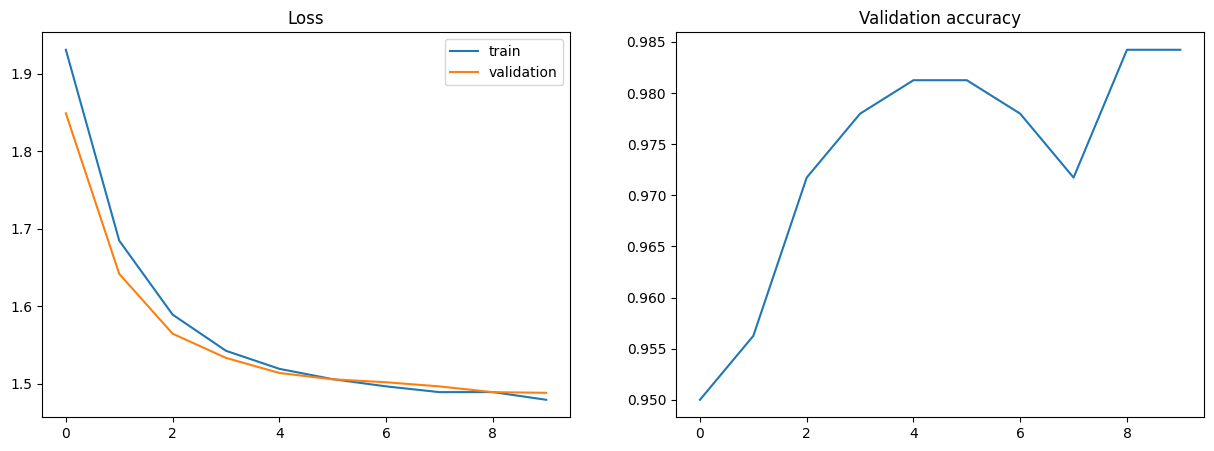

In [72]:
plot_train_process(train_loss, val_loss, val_accuracy)

```

```

```

```

```

```

```

```

```

```
### More about pytorch:
* Using torch on GPU and multi-GPU - [link](http://pytorch.org/docs/master/notes/cuda.html)
* More tutorials on pytorch - [link](http://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html)
* Pytorch examples - a repo that implements many cool DL models in pytorch - [link](https://github.com/pytorch/examples)
* Practical pytorch - a repo that implements some... other cool DL models... yes, in pytorch - [link](https://github.com/spro/practical-pytorch)
* And some more - [link](https://www.reddit.com/r/pytorch/comments/6z0yeo/pytorch_and_pytorch_tricks_for_kaggle/)